In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv


file path

In [4]:
df=pd.read_csv("/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


data info

In [5]:
print("--- Data Info ---")
df.info()

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    obje

In [6]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [7]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


train model

In [10]:
from sklearn.model_selection import train_test_split
df_encoded = df.copy()


X and y

In [11]:
y = df['G3'] 
X = df.drop(['G3'], axis=1)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

X_train shape: (316, 32)
X_valid shape: (79, 32)


In [12]:
from sklearn.preprocessing import OrdinalEncoder

# 1. Identify categorical columns
categorical_cols = [cname for cname in X_train.columns if X_train[cname].dtype == "object"]

# 2. Make copies to keep original data safe
X_train_encoded = X_train.copy()
X_valid_encoded = X_valid.copy()

# 3. Apply Ordinal Encoder
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_encoded[categorical_cols] = ordinal_encoder.fit_transform(X_train[categorical_cols])
X_valid_encoded[categorical_cols] = ordinal_encoder.transform(X_valid[categorical_cols])

print("Categorical columns encoded successfully!")
print("New shape of X_train:", X_train_encoded.shape)

Categorical columns encoded successfully!
New shape of X_train: (316, 32)


In [18]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. Initialize the XGBoost model
model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    random_state=0, 
    early_stopping_rounds=5,
    n_jobs=-1
)

# 2. Train the model with early stopping
model.fit(
    X_train_encoded, 
    y_train,
    eval_set=[(X_valid_encoded, y_valid)],
    verbose=False
)

# 3. Make predictions on the validation set
predictions = model.predict(X_valid_encoded)

# 4. Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_valid, predictions)

print(f"Validation MAE: {mae:.4f}")

Validation MAE: 1.1812


In [20]:
# Drop G1 and G2 along with G3
X_real = df.drop(['G1', 'G2', 'G3'], axis=1)

# Split again
X_tr, X_val, y_tr, y_val = train_test_split(X_real, y, test_size=0.2, random_state=0)

# Encode
X_tr_enc = X_tr.copy()
X_val_enc = X_val.copy()
X_tr_enc[categorical_cols] = ordinal_encoder.fit_transform(X_tr[categorical_cols])
X_val_enc[categorical_cols] = ordinal_encoder.transform(X_val[categorical_cols])

# Train and predict
model.fit(X_tr_enc, y_tr,eval_set=[(X_val_enc, y_val)],
    verbose=False)
preds = model.predict(X_val_enc)
print("Realistic MAE without G1 and G2:", mean_absolute_error(y_val, preds))

Realistic MAE without G1 and G2: 3.5812602043151855


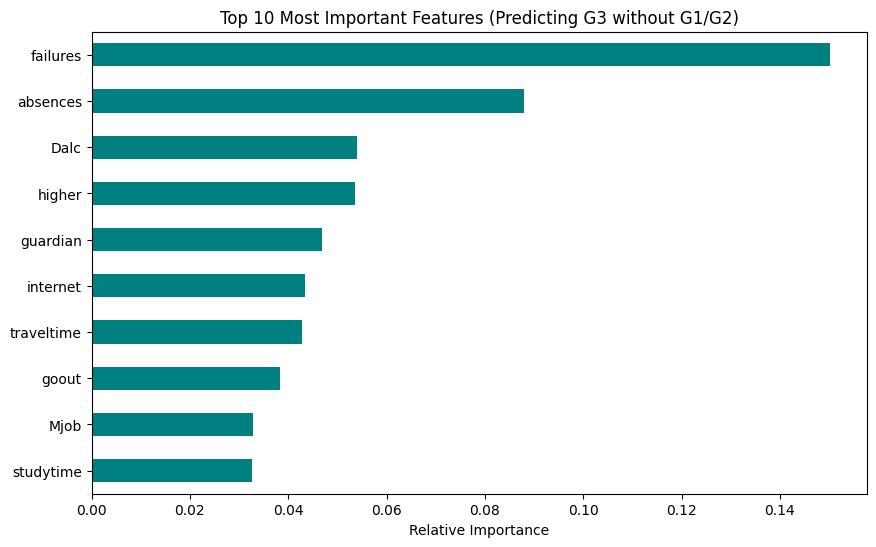

In [21]:
import matplotlib.pyplot as plt

# 1. Get feature importances from XGBoost
importance = model.feature_importances_
feature_names = X_tr_enc.columns

# 2. Create a Pandas Series for sorting
feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=True)

# 3. Plot the top 10 most important features
plt.figure(figsize=(10, 6))
feat_imp.tail(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features (Predicting G3 without G1/G2)')
plt.xlabel('Relative Importance')
plt.show()